# DQN WITH PRECEDENCE NETWORK — CartPole-v1 (full)

Entraîne DQN avec le World Model (Precedence Network) pour **vérifier les actions avant exécution**.

- **Config 1** : S(t+1) direct
- **Config 2** : S(t+5) direct (rollout greedy Q-network + WM auxiliaire Config 1)
- **Config 3** : ΔS = S(t+1) − S(t)

Ce notebook complet :
- entraîne les 3 configs avec precedence
- évalue en greedy (métriques étendues)
- sauvegarde les agents DQN via `torch.save` pour `DQN_ablation_CARTPOLE.py`


## 1. Imports & Setup

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import gymnasium as gym
import random
from collections import deque
from datetime import datetime
import json

# ──────────────────────────────────────────────
# Configuration
# ──────────────────────────────────────────────
ENV_NAME = "CartPole-v1"
DATA_PATH = "../data/collected/CartPole"
CHECKPOINT_DIR = "checkpoints_dqn_with_precedence_CartPole"
PLOT_DIR = "plots_with_precedence"
WORLD_MODEL_DIR = "world_model/checkpoints_CartPole"

# Hyperparamètres RL
N_EPISODES = 500
MAX_STEPS_PER_EPISODE = 500
BATCH_SIZE = 64
LR = 1e-3
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_END = 0.01
EPSILON_DECAY = 0.995
TARGET_UPDATE = 10
BUFFER_SIZE = 50000

# Évaluation greedy (post-entraînement, pour ablation)
EVAL_N_EPISODES = 30
SOLVE_THRESHOLD = 500.0   # CartPole-v1 solved
ABLATION_CKPT_PREFIX = "dqn_prec_cartpole_config"

# Seed
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Créer répertoires
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

# Random seed
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

print(f"✅ Setup OK")
print(f"  Device: {DEVICE}")
print(f"  Environment: {ENV_NAME}")
print(f"  Data path: {DATA_PATH}")


✅ Setup OK
  Device: cpu
  Environment: CartPole-v1
  Data path: ../data/collected/CartPole


## 2. Charger les données de normalisation

In [2]:
scaler_path = os.path.join(DATA_PATH, "scaler.npz")
scaler = np.load(scaler_path, allow_pickle=True)

STATE_MEAN = scaler["state_mean"].astype(np.float32)
STATE_STD  = scaler["state_std"].astype(np.float32)

STATE_DIM  = 4
ACTION_DIM = 2

print(f"\n📦 Scaler chargé")
print(f"  STATE_DIM:  {STATE_DIM}")
print(f"  ACTION_DIM: {ACTION_DIM}")
print(f"  State mean: {STATE_MEAN}")
print(f"  State std:  {STATE_STD}")



📦 Scaler chargé
  STATE_DIM:  4
  ACTION_DIM: 2
  State mean: [-0.00020712 -0.02029223  0.00405843  0.02626351]
  State std:  [0.48820907 0.80932426 0.12245946 0.66561514]


## 3. Architecture WorldModel (chargement)

In [3]:
class WorldModel(nn.Module):
    """
    Réseau de prédiction d'état (3 configs).

    Config 1 : in = obs_dim + act_dim              → S(t+1) absolu
    Config 2 : in = obs_dim + n_step * act_dim     → S(t+n) absolu
    Config 3 : in = obs_dim + act_dim              → ΔS  (S+ΔS dans predict())
    """

    def __init__(self, obs_dim: int, act_dim: int,
                 config: int = 1, n_step: int = 5, hidden: int = 64):
        super().__init__()
        assert config in (1, 2, 3), "config doit être 1, 2 ou 3"

        self.obs_dim  = obs_dim
        self.act_dim  = act_dim
        self.config   = config
        self.n_step   = n_step

        in_dim = obs_dim + (n_step * act_dim if config == 2 else act_dim)

        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, obs_dim),
        )

    def forward(self, state: torch.Tensor,
                action_input: torch.Tensor) -> torch.Tensor:
        return self.net(torch.cat([state, action_input], dim=-1))

    def predict(self, state: torch.Tensor,
                action_input: torch.Tensor) -> torch.Tensor:
        """Retourne toujours un état absolu (applique S+ΔS pour config 3)."""
        out = self.forward(state, action_input)
        return state + out if self.config == 3 else out


def load_world_model(config: int, checkpoint_dir=WORLD_MODEL_DIR):
    """Charger le world model entraîné pour une configuration donnée."""
    model = WorldModel(STATE_DIM, ACTION_DIM, config=config, n_step=5, hidden=64).to(DEVICE)

    ckpt_path = os.path.join(checkpoint_dir, f"wm_{ENV_NAME}_config{config}.pt")
    if config == 2:
        ckpt_path = os.path.join(checkpoint_dir, f"wm_{ENV_NAME}_config{config}_n5.pt")

    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt["state_dict"])
        model.eval()
        print(f"✅ Config {config} world model chargé: {ckpt_path}")
        return model
    else:
        print(f"❌ Fichier non trouvé: {ckpt_path}")
        return None


print("✅ Architecture WorldModel définie")


✅ Architecture WorldModel définie


## 4. ActionVerifier — Stratégies de vérification

**Config 2 — Rollout greedy (Option 2) :**  
Pour construire le vecteur `[a0 | a1 | ... | a4]` requis par Config 2, on simule la trajectoire future :
- `a0` = action qu'on veut vérifier  
- `a1…a4` = actions greedy du Q-network sur les états successifs prédits par le **World Model auxiliaire Config 1**  

C'est la seule approche cohérente avec la sémantique de Config 2 (S(t+5) sous une vraie politique).


In [4]:
class ActionVerifier:
    """
    Vérifie si une action est "bonne" en prédisant le prochain état
    avec le World Model (Precedence Network).

    Pour Config 2, utilise un rollout greedy :
      - a0 = action candidate
      - a1…a_{n-1} = actions greedy du Q-network propagées via le world model auxiliaire (Config 1)
    """

    def __init__(self, world_model: WorldModel, config: int,
                 safety_threshold: float = 0.3,
                 stability_threshold: float = 0.5,
                 aux_model: WorldModel = None,
                 agent_qnet: nn.Module = None):
        """
        Args:
            world_model       : modèle principal (config 1, 2 ou 3)
            config            : configuration du world model
            safety_threshold  : seuil de sécurité
            stability_threshold: seuil de stabilité
            aux_model         : world model Config 1, utilisé pour propager les états
                                intermédiaires lors du rollout Config 2
            agent_qnet        : Q-network de l'agent, utilisé pour les actions greedy
                                du rollout Config 2
        """
        self.model              = world_model
        self.config             = config
        self.safety_threshold   = safety_threshold
        self.stability_threshold= stability_threshold
        self.aux_model          = aux_model   # Config 1 — pour rollout interne
        self.agent_qnet         = agent_qnet  # Q-network — pour actions greedy

        # Bounds CartPole
        self.pole_angle_safe_bound    = 0.2   # ~12 degrés
        self.cart_position_safe_bound = 2.0

    # ──────────────────────────────────────────────────────────────────
    # CONSTRUCTION DU VECTEUR D'ACTIONS POUR CONFIG 2
    # ──────────────────────────────────────────────────────────────────
    @torch.no_grad()
    def _build_action_sequence_config2(self, state_t: torch.Tensor,
                                       first_action: int) -> torch.Tensor:
        """
        Construit le vecteur d'actions [a0|a1|...|a_{n-1}] pour Config 2
        via un rollout greedy Q-network + World Model auxiliaire Config 1.

        Args:
            state_t      : état courant (1, STATE_DIM), normalisé
            first_action : action candidate à vérifier (a0)

        Returns:
            action_input : (1, n_step * ACTION_DIM)
        """
        n_step     = self.model.n_step  # = 5
        actions_seq= []
        state_loop = state_t.clone()   # (1, STATE_DIM)

        for step in range(n_step):
            # Choisir l'action de ce step
            if step == 0:
                a = first_action  # action candidate imposée
            elif self.agent_qnet is not None:
                # Greedy depuis le Q-network sur l'état simulé
                q_vals = self.agent_qnet(state_loop)
                a = q_vals.argmax(1).item()
            else:
                a = first_action  # fallback conservateur

            # One-hot
            a_oh = torch.zeros(ACTION_DIM, device=DEVICE)
            a_oh[a] = 1.0
            actions_seq.append(a_oh)

            # Propager l'état via le world model auxiliaire Config 1
            # (sauf au dernier step où on n'en a plus besoin)
            if step < n_step - 1:
                if self.aux_model is not None:
                    state_loop = self.aux_model.predict(state_loop, a_oh.unsqueeze(0))
                else:
                    # Pas d'aux_model : on garde le même état (dégradé mais valide)
                    pass

        # Concaténer : (1, n_step * ACTION_DIM)
        action_input = torch.cat(actions_seq).unsqueeze(0)
        return action_input

    # ──────────────────────────────────────────────────────────────────
    # PRÉDICTION DE L'ÉTAT SUIVANT
    # ──────────────────────────────────────────────────────────────────
    @torch.no_grad()
    def predict_next_state(self, state_np: np.ndarray, action: int) -> tuple:
        """
        Prédire le prochain état avec le world model.

        Returns:
            predicted_state_np : état prédit (np.array, normalisé)
            error              : 0.0 (placeholder)
        """
        state_t = torch.FloatTensor(state_np).unsqueeze(0).to(DEVICE)  # (1, STATE_DIM)

        if self.config == 2:
            # Rollout greedy pour construire la séquence d'actions complète
            action_input = self._build_action_sequence_config2(state_t, action)
        else:
            # Config 1 & 3 : simple one-hot
            action_input = torch.zeros(1, ACTION_DIM, device=DEVICE)
            action_input[0, action] = 1.0

        predicted_state_t  = self.model.predict(state_t, action_input)
        predicted_state_np = predicted_state_t.cpu().numpy()[0]
        return predicted_state_np, 0.0

    # ──────────────────────────────────────────────────────────────────
    # VÉRIFICATION PRINCIPALE
    # ──────────────────────────────────────────────────────────────────
    @torch.no_grad()
    def verify_action_cartpole(self, state_np: np.ndarray, action: int,
                                strategy: str = 'combined') -> tuple:
        """
        Vérifier si une action est bonne pour CartPole.

        Stratégies:
        - 'safety'   : vérifier que l'état reste dans les bounds
        - 'stability': vérifier la stabilité avec perturbations multiples
        - 'combined' : combinaison des deux

        Returns:
            is_valid   : True si l'action est bonne
            confidence : score de confiance [0, 1]
            details    : dict avec les détails de la vérification
        """
        details = {
            'strategy'       : strategy,
            'predicted_state': None,
            'pole_angle'     : None,
            'cart_position'  : None,
            'safety_ok'      : False,
            'stability_ok'   : False,
            'is_valid'       : False,
            'confidence'     : 0.0,
        }

        # ════════════════════════════════════════════════════════════
        # STRATÉGIE 1 : VÉRIFICATION DE SÉCURITÉ
        # ════════════════════════════════════════════════════════════
        predicted_state, _ = self.predict_next_state(state_np, action)

        # CartPole state : [x, x_dot, theta, theta_dot]
        pole_angle    = abs(predicted_state[2])
        cart_position = abs(predicted_state[0])

        angle_ok    = pole_angle    < self.pole_angle_safe_bound
        position_ok = cart_position < self.cart_position_safe_bound
        safety_ok   = angle_ok and position_ok

        details['predicted_state'] = predicted_state
        details['pole_angle']      = float(pole_angle)
        details['cart_position']   = float(cart_position)
        details['safety_ok']       = bool(safety_ok)

        if strategy in ['safety', 'combined']:
            if not safety_ok:
                details['is_valid']   = False
                details['confidence'] = 0.0
                return False, 0.0, details

        # ════════════════════════════════════════════════════════════
        # STRATÉGIE 2 : VÉRIFICATION DE STABILITÉ
        # ════════════════════════════════════════════════════════════
        variance = 0.0
        stability_ok = True

        if strategy in ['stability', 'combined']:
            predictions = []
            n_iterations = 5

            for i in range(n_iterations):
                noise_scale    = 0.01 if i > 0 else 0.0
                perturbed_state = state_np + np.random.randn(STATE_DIM) * noise_scale
                pred, _        = self.predict_next_state(perturbed_state, action)
                predictions.append(pred)

            predictions_arr = np.array(predictions)
            variance        = float(np.mean(np.var(predictions_arr, axis=0)))
            stability_ok    = variance < self.stability_threshold

            details['stability_ok']        = bool(stability_ok)
            details['prediction_variance'] = variance

            if not stability_ok and strategy == 'stability':
                details['is_valid']   = False
                details['confidence'] = 0.5
                return False, 0.5, details

        # ════════════════════════════════════════════════════════════
        # DÉCISION FINALE
        # ════════════════════════════════════════════════════════════
        if strategy == 'safety':
            is_valid   = safety_ok
            confidence = 1.0 if is_valid else 0.0

        elif strategy == 'stability':
            is_valid   = stability_ok
            confidence = 1.0 - min(variance / self.stability_threshold, 1.0)

        else:  # 'combined'
            is_valid      = safety_ok
            safety_score  = 1.0 if safety_ok else 0.0
            stab_score    = 1.0 - min(variance / self.stability_threshold, 1.0)                             if 'prediction_variance' in details else 0.5
            confidence    = (safety_score + stab_score) / 2.0

        details['is_valid']   = bool(is_valid)
        details['confidence'] = float(confidence)
        return is_valid, confidence, details


print("✅ ActionVerifier défini (Config 2 : rollout greedy Q-network + WM auxiliaire)")


✅ ActionVerifier défini (Config 2 : rollout greedy Q-network + WM auxiliaire)


## 5. DQN Agent

In [5]:
class ReplayBuffer:
    """Circular replay buffer for experience storage."""

    def __init__(self, capacity: int = BUFFER_SIZE):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states,      dtype=np.float32),
            np.array(actions,     dtype=np.int32),
            np.array(rewards,     dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones,       dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)


class QNetwork(nn.Module):
    """Q-network for CartPole."""

    def __init__(self, state_dim: int, action_dim: int, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden,    hidden), nn.ReLU(),
            nn.Linear(hidden, action_dim),
        )

    def forward(self, x):
        return self.net(x)


class DQNAgent:
    """DQN Agent with optional precedence network verification."""

    def __init__(self, use_precedence: bool = False,
                 world_model: WorldModel = None,
                 verifier: ActionVerifier = None,
                 verify_strategy: str = 'combined'):

        self.state_dim       = STATE_DIM
        self.action_dim      = ACTION_DIM
        self.use_precedence  = use_precedence
        self.world_model     = world_model
        self.verifier        = verifier
        self.verify_strategy = verify_strategy

        # Q-networks
        self.q_net     = QNetwork(STATE_DIM, ACTION_DIM).to(DEVICE)
        self.target_net= QNetwork(STATE_DIM, ACTION_DIM).to(DEVICE)
        self.target_net.load_state_dict(self.q_net.state_dict())

        # Optimizer
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=LR)
        self.criterion = nn.MSELoss()

        # RL parameters
        self.epsilon = EPSILON_START
        self.gamma   = GAMMA

        # Replay buffer
        self.replay_buffer = ReplayBuffer(BUFFER_SIZE)

        # Stats
        self.actions_verified        = 0
        self.actions_skipped         = 0
        self.actions_executed_unsafe = 0
        self.verification_history    = []

    def select_action_epsilon_greedy(self, state: np.ndarray) -> int:
        if np.random.random() < self.epsilon:
            return np.random.randint(self.action_dim)
        state_t = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            return self.q_net(state_t).argmax(1).item()

    def select_action_with_verification(self, state: np.ndarray) -> tuple:
        """
        Sélectionner une action ET la vérifier avec le precedence network.
        Pour Config 2, le verifier utilise le rollout greedy (Option 2).
        """
        # ── Mettre à jour la référence au Q-network dans le verifier ──
        # (le Q-network évolue au fil de l'entraînement)
        if self.verifier is not None and self.verifier.config == 2:
            self.verifier.agent_qnet = self.q_net

        if np.random.random() < self.epsilon:
            recommended_action = np.random.randint(self.action_dim)
        else:
            state_t = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                recommended_action = self.q_net(state_t).argmax(1).item()

        is_valid, confidence, details = self.verifier.verify_action_cartpole(
            state, recommended_action, strategy=self.verify_strategy
        )
        details['recommended_action'] = recommended_action

        if is_valid:
            self.actions_verified += 1
            self.verification_history.append(details)
            return recommended_action, True, details

        # Essayer les alternatives
        for alt_action in [a for a in range(self.action_dim) if a != recommended_action]:
            is_valid, confidence, details_alt = self.verifier.verify_action_cartpole(
                state, alt_action, strategy=self.verify_strategy
            )
            if is_valid:
                self.actions_verified += 1
                details_alt['recommended_action'] = recommended_action
                details_alt['alternative_action'] = alt_action
                self.verification_history.append(details_alt)
                return alt_action, True, details_alt

        # Aucune action valide → exécuter quand même
        self.actions_skipped += 1
        details['no_valid_alternative'] = True
        self.verification_history.append(details)
        return recommended_action, False, details

    def store_experience(self, state, action, reward, next_state, done):
        self.replay_buffer.add(state, action, reward, next_state, done)

    def train_step(self) -> float:
        if len(self.replay_buffer) < BATCH_SIZE:
            return None

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(BATCH_SIZE)

        states_t     = torch.FloatTensor(states).to(DEVICE)
        actions_t    = torch.LongTensor(actions).to(DEVICE)
        rewards_t    = torch.FloatTensor(rewards).to(DEVICE)
        next_states_t= torch.FloatTensor(next_states).to(DEVICE)
        dones_t      = torch.FloatTensor(dones).to(DEVICE)

        q_values = self.q_net(states_t).gather(1, actions_t.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            best_actions = self.q_net(next_states_t).argmax(1)
            max_q_next   = self.target_net(next_states_t).gather(1, best_actions.unsqueeze(1)).squeeze(1)
            target_q     = rewards_t + self.gamma * max_q_next * (1 - dones_t)

        loss = self.criterion(q_values, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_net.parameters(), 1.0)
        self.optimizer.step()
        return loss.item()

    def update_target_network(self):
        self.target_net.load_state_dict(self.q_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(EPSILON_END, self.epsilon * EPSILON_DECAY)


print("✅ DQN Agent défini")


✅ DQN Agent défini


## 6. Boucle d'entraînement

In [6]:
def train_dqn_episode(agent: DQNAgent, env,
                      max_steps: int = MAX_STEPS_PER_EPISODE,
                      use_precedence: bool = False) -> tuple:
    state, _ = env.reset()
    state_norm = (state - STATE_MEAN) / (STATE_STD + 1e-8)

    episode_reward = 0
    verified_count = 0
    skipped_count  = 0

    for step in range(max_steps):
        if use_precedence:
            action, is_verified, details = agent.select_action_with_verification(state_norm)
            if is_verified:
                verified_count += 1
            else:
                skipped_count  += 1
        else:
            action = agent.select_action_epsilon_greedy(state_norm)

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        next_state_norm = (next_state - STATE_MEAN) / (STATE_STD + 1e-8)
        agent.store_experience(state_norm, action, reward, next_state_norm, done)

        if len(agent.replay_buffer) > 64:
            agent.train_step()

        episode_reward += reward
        state_norm      = next_state_norm

        if done:
            break

    return episode_reward, verified_count, skipped_count


@torch.no_grad()
def evaluate_agent_greedy(agent: DQNAgent, n_episodes: int = EVAL_N_EPISODES,
                          use_precedence: bool = False,
                          seed_offset: int = 1000) -> dict:
    """
    Évaluation greedy (ε=0) sur n_episodes.
    Retourne un dict de métriques pour rapport / ablation.
    """
    env = gym.make(ENV_NAME)
    rewards, lengths = [], []
    verified_eps, skipped_eps = [], []
    alt_action_count = 0
    total_steps = 0

    q_net_was_training = agent.q_net.training
    agent.q_net.eval()

    for ep in range(n_episodes):
        state, _ = env.reset(seed=SEED + seed_offset + ep)
        state_norm = (state - STATE_MEAN) / (STATE_STD + 1e-8)
        ep_reward, ep_len = 0.0, 0
        ep_verified, ep_skipped = 0, 0

        for _ in range(MAX_STEPS_PER_EPISODE):
            if use_precedence and agent.verifier is not None:
                saved_eps = agent.epsilon
                agent.epsilon = 0.0
                action, is_verified, details = agent.select_action_with_verification(state_norm)
                agent.epsilon = saved_eps
                if is_verified:
                    ep_verified += 1
                else:
                    ep_skipped += 1
                if details.get("alternative_action") is not None:
                    alt_action_count += 1
            else:
                state_t = torch.FloatTensor(state_norm).unsqueeze(0).to(DEVICE)
                action = int(agent.q_net(state_t).argmax(1).item())

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            state_norm = (next_state - STATE_MEAN) / (STATE_STD + 1e-8)
            ep_reward += reward
            ep_len += 1
            total_steps += 1
            if done:
                break

        rewards.append(ep_reward)
        lengths.append(ep_len)
        verified_eps.append(ep_verified)
        skipped_eps.append(ep_skipped)

    env.close()
    if q_net_was_training:
        agent.q_net.train()

    rewards_arr = np.array(rewards, dtype=np.float32)
    lengths_arr = np.array(lengths, dtype=np.float32)
    success_rate = float(np.mean(rewards_arr >= SOLVE_THRESHOLD))

    metrics = {
        "eval_rewards": rewards,
        "eval_lengths": lengths,
        "eval_mean": float(np.mean(rewards_arr)),
        "eval_std": float(np.std(rewards_arr)),
        "eval_min": float(np.min(rewards_arr)),
        "eval_max": float(np.max(rewards_arr)),
        "eval_median": float(np.median(rewards_arr)),
        "eval_length_mean": float(np.mean(lengths_arr)),
        "eval_length_std": float(np.std(lengths_arr)),
        "success_rate": success_rate,
        "n_solved": int(np.sum(rewards_arr >= SOLVE_THRESHOLD)),
        "n_episodes": n_episodes,
        "total_steps": total_steps,
    }
    if use_precedence:
        metrics["eval_verified_mean"] = float(np.mean(verified_eps))
        metrics["eval_skipped_mean"] = float(np.mean(skipped_eps))
        metrics["eval_alt_action_rate"] = alt_action_count / max(total_steps, 1)

    return metrics


def train_agent_with_config(config: int, use_precedence: bool = False,
                            verify_strategy: str = 'combined',
                            n_episodes: int = N_EPISODES):
    """
    Entraîner un agent DQN avec une configuration du world model donnée.
    Inclut évaluation greedy post-entraînement.
    """
    print(f"\n{'='*80}")
    print(f"  DQN Training — Config {config} | Use Precedence: {use_precedence}")
    print(f"  Environment: {ENV_NAME}")
    if use_precedence:
        print(f"  Verification Strategy: {verify_strategy}")
        if config == 2:
            print(f"  Config 2 : rollout greedy (Q-network + WM auxiliaire Config 1)")
    print(f"{'='*80}\n")

    env = gym.make(ENV_NAME)

    world_model = load_world_model(config)
    if world_model is None:
        print(f"❌ Impossible de charger le world model pour config {config}")
        return None

    aux_model = None
    if use_precedence and config == 2:
        aux_model = load_world_model(1)
        if aux_model is None:
            print("⚠️  World model auxiliaire Config 1 introuvable — rollout dégradé")

    agent = DQNAgent(
        use_precedence=use_precedence,
        world_model=world_model if use_precedence else None,
        verifier=None,
    )

    if use_precedence:
        agent.verifier = ActionVerifier(
            world_model=world_model,
            config=config,
            safety_threshold=0.3,
            stability_threshold=0.5,
            aux_model=aux_model,
            agent_qnet=agent.q_net,
        )
        agent.verify_strategy = verify_strategy

    episode_rewards, episode_verified, episode_skipped = [], [], []
    total_loss = []

    for episode in range(n_episodes):
        episode_reward, verified, skipped = train_dqn_episode(
            agent, env, use_precedence=use_precedence
        )
        episode_rewards.append(episode_reward)
        episode_verified.append(verified)
        episode_skipped.append(skipped)

        for _ in range(10):
            loss = agent.train_step()
            if loss is not None:
                total_loss.append(loss)

        if (episode + 1) % TARGET_UPDATE == 0:
            agent.update_target_network()

        agent.decay_epsilon()

        if (episode + 1) % 20 == 0:
            avg_reward = np.mean(episode_rewards[-20:])
            print(f"  Episode {episode+1:3d}/{n_episodes} | "
                  f"Avg Reward: {avg_reward:7.2f} | "
                  f"ε: {agent.epsilon:.3f}", end="")
            if use_precedence:
                print(f" | Verified: {np.mean(episode_verified[-20:]):.1f} | "
                      f"Skipped: {np.mean(episode_skipped[-20:]):.1f}")
            else:
                print()

    env.close()

    print(f"\n  [Eval] Greedy evaluation ({EVAL_N_EPISODES} episodes)...")
    eval_metrics = evaluate_agent_greedy(
        agent, n_episodes=EVAL_N_EPISODES, use_precedence=use_precedence
    )
    print(f"  [Eval] Mean reward: {eval_metrics['eval_mean']:.2f} ± {eval_metrics['eval_std']:.2f} "
          f"(min={eval_metrics['eval_min']:.0f}, max={eval_metrics['eval_max']:.0f})")
    print(f"  [Eval] Success rate (≥{SOLVE_THRESHOLD:.0f}): "
          f"{100*eval_metrics['success_rate']:.1f}% "
          f"({eval_metrics['n_solved']}/{eval_metrics['n_episodes']})")
    print(f"  [Eval] Mean episode length: {eval_metrics['eval_length_mean']:.1f}")
    if use_precedence:
        print(f"  [Eval] Verified/step: {eval_metrics.get('eval_verified_mean', 0):.2f} | "
              f"Skipped/step: {eval_metrics.get('eval_skipped_mean', 0):.2f}")

    return {
        'config': config,
        'use_precedence': use_precedence,
        'verify_strategy': verify_strategy,
        'agent': agent,
        'rewards': episode_rewards,
        'verified': episode_verified,
        'skipped': episode_skipped,
        'losses': total_loss,
        **eval_metrics,
    }


print("✅ Fonctions d'entraînement et d'évaluation définies")


✅ Fonctions d'entraînement et d'évaluation définies


## 7. Entraînement — Config 1 (S(t+1) direct)

In [7]:
results_config1_with_prec = train_agent_with_config(
    config=1,
    use_precedence=True,
    verify_strategy='combined',
    n_episodes=N_EPISODES
)



  DQN Training — Config 1 | Use Precedence: True
  Environment: CartPole-v1
  Verification Strategy: combined

✅ Config 1 world model chargé: world_model/checkpoints_CartPole/wm_CartPole-v1_config1.pt
  Episode  20/500 | Avg Reward:   21.35 | ε: 0.905 | Verified: 6.0 | Skipped: 15.4
  Episode  40/500 | Avg Reward:   30.40 | ε: 0.818 | Verified: 6.3 | Skipped: 24.1
  Episode  60/500 | Avg Reward:   26.05 | ε: 0.740 | Verified: 5.7 | Skipped: 20.4
  Episode  80/500 | Avg Reward:   37.40 | ε: 0.670 | Verified: 5.8 | Skipped: 31.6
  Episode 100/500 | Avg Reward:   44.45 | ε: 0.606 | Verified: 3.6 | Skipped: 40.8
  Episode 120/500 | Avg Reward:   35.85 | ε: 0.548 | Verified: 3.9 | Skipped: 31.9
  Episode 140/500 | Avg Reward:   51.65 | ε: 0.496 | Verified: 4.7 | Skipped: 47.0
  Episode 160/500 | Avg Reward:   35.95 | ε: 0.448 | Verified: 3.8 | Skipped: 32.1
  Episode 180/500 | Avg Reward:   44.90 | ε: 0.406 | Verified: 4.3 | Skipped: 40.6
  Episode 200/500 | Avg Reward:   21.35 | ε: 0.367 

## 8. Entraînement — Config 2 (S(t+5) direct — rollout greedy)

Le verifier construit la séquence `[a0|a1|a2|a3|a4]` comme suit :
- **a0** = action candidate à vérifier
- **a1…a4** = actions greedy du Q-network sur les états simulés successivement par le World Model Config 1


In [15]:
results_config2_with_prec = train_agent_with_config(
    config=2,
    use_precedence=True,
    verify_strategy='combined',
    n_episodes=N_EPISODES
)



  DQN Training — Config 2 | Use Precedence: True
  Environment: CartPole-v1
  Verification Strategy: combined
  Config 2 : rollout greedy (Q-network + WM auxiliaire Config 1)

✅ Config 2 world model chargé: world_model/checkpoints_CartPole/wm_CartPole-v1_config2_n5.pt
✅ Config 1 world model chargé: world_model/checkpoints_CartPole/wm_CartPole-v1_config1.pt
  Episode  20/500 | Avg Reward:   56.10 | ε: 0.905 | Verified: 29.2 | Skipped: 26.9
  Episode  40/500 | Avg Reward:   37.20 | ε: 0.818 | Verified: 15.0 | Skipped: 22.2
  Episode  60/500 | Avg Reward:   35.40 | ε: 0.740 | Verified: 15.2 | Skipped: 20.1
  Episode  80/500 | Avg Reward:  116.00 | ε: 0.670 | Verified: 85.4 | Skipped: 30.6
  Episode 100/500 | Avg Reward:  173.85 | ε: 0.606 | Verified: 114.0 | Skipped: 59.9
  Episode 120/500 | Avg Reward:  133.05 | ε: 0.548 | Verified: 86.0 | Skipped: 47.1
  Episode 140/500 | Avg Reward:  164.15 | ε: 0.496 | Verified: 100.5 | Skipped: 63.6
  Episode 160/500 | Avg Reward:   72.70 | ε: 0.448

## 9. Entraînement — Config 3 (ΔS)

In [25]:
results_config3_with_prec = train_agent_with_config(
    config=3,
    use_precedence=True,
    verify_strategy='combined',
    n_episodes=N_EPISODES
)



  DQN Training — Config 3 | Use Precedence: True
  Environment: CartPole-v1
  Verification Strategy: combined

✅ Config 3 world model chargé: world_model/checkpoints_CartPole/wm_CartPole-v1_config3.pt
  Episode  20/500 | Avg Reward:   17.55 | ε: 0.905 | Verified: 3.9 | Skipped: 13.7
  Episode  40/500 | Avg Reward:   19.30 | ε: 0.818 | Verified: 4.2 | Skipped: 15.1
  Episode  60/500 | Avg Reward:   21.55 | ε: 0.740 | Verified: 4.5 | Skipped: 17.0
  Episode  80/500 | Avg Reward:   34.50 | ε: 0.670 | Verified: 7.2 | Skipped: 27.4
  Episode 100/500 | Avg Reward:   44.15 | ε: 0.606 | Verified: 11.2 | Skipped: 33.0
  Episode 120/500 | Avg Reward:   56.45 | ε: 0.548 | Verified: 11.6 | Skipped: 44.9
  Episode 140/500 | Avg Reward:   59.95 | ε: 0.496 | Verified: 6.7 | Skipped: 53.2
  Episode 160/500 | Avg Reward:   82.70 | ε: 0.448 | Verified: 5.3 | Skipped: 77.3
  Episode 180/500 | Avg Reward:   41.75 | ε: 0.406 | Verified: 4.2 | Skipped: 37.5
  Episode 200/500 | Avg Reward:   63.35 | ε: 0.36

## 10. Analyse & Comparaison

In [26]:
print(f"\n{'='*80}")
print(f"  RÉSUMÉ — DQN WITH PRECEDENCE NETWORK — {ENV_NAME}")
print(f"{'='*80}\n")

all_results = [
    results_config1_with_prec,
    results_config2_with_prec,
    results_config3_with_prec,
]

header = (f"{'Config':<8} {'Train(50)':>12} {'Eval mean':>12} {'Eval std':>10} "
          f"{'Success%':>10} {'Verified/ep':>12} {'Skipped/ep':>12}")
print(header)
print("-" * len(header))

for res in all_results:
    if res is None:
        continue
    config = res['config']
    train_mean = np.mean(res['rewards'][-50:])
    train_std  = np.std(res['rewards'][-50:])
    print(f"Config {config:<2} {train_mean:>8.2f}±{train_std:<5.2f} "
          f"{res['eval_mean']:>12.2f} {res['eval_std']:>10.2f} "
          f"{100*res['success_rate']:>9.1f}% "
          f"{np.mean(res['verified'][-50:]):>12.1f} "
          f"{np.mean(res['skipped'][-50:]):>12.1f}")

print()
for res in all_results:
    if res is None:
        continue
    config = res['config']
    print(f"Config {config} — détails:")
    print(f"  Train (last 50):  {np.mean(res['rewards'][-50:]):.2f} ± {np.std(res['rewards'][-50:]):.2f}")
    print(f"  Eval greedy:      {res['eval_mean']:.2f} ± {res['eval_std']:.2f} "
          f"(median={res['eval_median']:.0f}, min={res['eval_min']:.0f}, max={res['eval_max']:.0f})")
    print(f"  Solved episodes:  {res['n_solved']}/{res['n_episodes']} "
          f"({100*res['success_rate']:.1f}%)")
    print(f"  Mean ep length:   {res['eval_length_mean']:.1f} ± {res['eval_length_std']:.1f}")
    if res.get('eval_verified_mean') is not None:
        print(f"  Eval verified/ep: {res['eval_verified_mean']:.2f}")
        print(f"  Eval skipped/ep:  {res['eval_skipped_mean']:.2f}")
        print(f"  Alt-action rate:  {res.get('eval_alt_action_rate', 0)*100:.2f}%")
    print()

valid_results = [r for r in all_results if r is not None]
best_train = max(valid_results, key=lambda x: np.mean(x['rewards'][-50:]))
best_eval  = max(valid_results, key=lambda x: x['eval_mean'])
print(f"🏆 Meilleure config (train, last 50): Config {best_train['config']} "
      f"({np.mean(best_train['rewards'][-50:]):.2f})")
print(f"🏆 Meilleure config (eval greedy):    Config {best_eval['config']} "
      f"({best_eval['eval_mean']:.2f})")



  RÉSUMÉ — DQN WITH PRECEDENCE NETWORK — CartPole-v1

Config      Train(50)    Eval mean   Eval std   Success%  Verified/ep   Skipped/ep
----------------------------------------------------------------------------------
Config 1     85.86±41.78        98.20       1.78       0.0%          4.3         81.5
Config 2    140.10±119.42       399.43     166.77      73.3%         43.4         96.7
Config 3     81.90±40.90       101.03       1.62       0.0%          4.0         77.9

Config 1 — détails:
  Train (last 50):  85.86 ± 41.78
  Eval greedy:      98.20 ± 1.78 (median=98, min=95, max=103)
  Solved episodes:  0/30 (0.0%)
  Mean ep length:   98.2 ± 1.8
  Eval verified/ep: 2.30
  Eval skipped/ep:  95.90
  Alt-action rate:  0.00%

Config 2 — détails:
  Train (last 50):  140.10 ± 119.42
  Eval greedy:      399.43 ± 166.77 (median=500, min=120, max=500)
  Solved episodes:  22/30 (73.3%)
  Mean ep length:   399.4 ± 166.8
  Eval verified/ep: 214.80
  Eval skipped/ep:  184.63
  Alt-action rate

## 11. Visualisations

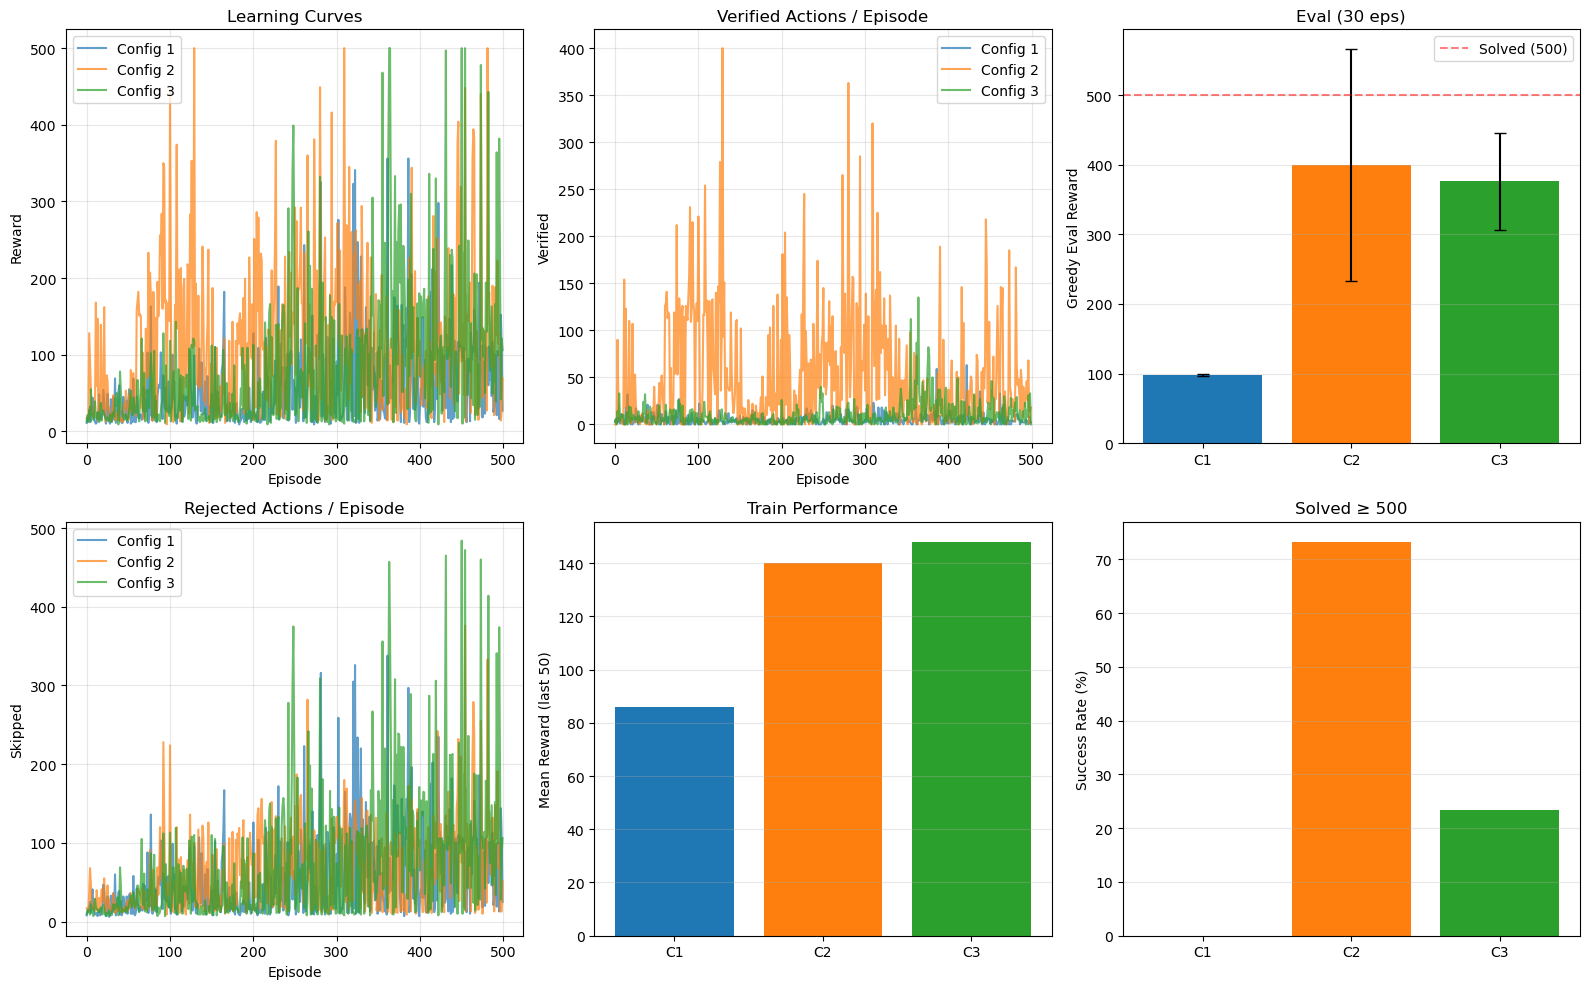

📊 Plot saved → plots_with_precedence/all_configs_with_precedence_full.png


In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

ax = axes[0, 0]
for res in all_results:
    if res is None:
        continue
    ax.plot(res['rewards'], alpha=0.7, label=f"Config {res['config']}")
ax.set_xlabel('Episode'); ax.set_ylabel('Reward')
ax.set_title('Learning Curves'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
for res in all_results:
    if res is None:
        continue
    ax.plot(res['verified'], alpha=0.7, label=f"Config {res['config']}")
ax.set_xlabel('Episode'); ax.set_ylabel('Verified')
ax.set_title('Verified Actions / Episode'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 2]
configs = [f"C{r['config']}" for r in all_results if r is not None]
eval_means = [r['eval_mean'] for r in all_results if r is not None]
eval_stds  = [r['eval_std']  for r in all_results if r is not None]
ax.bar(configs, eval_means, yerr=eval_stds, capsize=4, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.axhline(SOLVE_THRESHOLD, color='r', ls='--', alpha=0.5, label=f'Solved ({SOLVE_THRESHOLD:.0f})')
ax.set_ylabel('Greedy Eval Reward'); ax.set_title(f'Eval ({EVAL_N_EPISODES} eps)')
ax.legend(); ax.grid(axis='y', alpha=0.3)

ax = axes[1, 0]
for res in all_results:
    if res is None:
        continue
    ax.plot(res['skipped'], alpha=0.7, label=f"Config {res['config']}")
ax.set_xlabel('Episode'); ax.set_ylabel('Skipped')
ax.set_title('Rejected Actions / Episode'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 1]
train_final = [np.mean(r['rewards'][-50:]) for r in all_results if r is not None]
ax.bar([f"C{r['config']}" for r in all_results if r is not None], train_final,
       color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.set_ylabel('Mean Reward (last 50)'); ax.set_title('Train Performance'); ax.grid(axis='y', alpha=0.3)

ax = axes[1, 2]
success_rates = [100 * r['success_rate'] for r in all_results if r is not None]
ax.bar(configs, success_rates, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.set_ylabel('Success Rate (%)'); ax.set_title(f'Solved ≥ {SOLVE_THRESHOLD:.0f}'); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(PLOT_DIR, 'all_configs_with_precedence_full.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Plot saved → {plot_path}")


## 12. Detailed Analysis — Verification Statistics

In [12]:
print(f"\n{'='*80}")
print(f"  DETAILED VERIFICATION ANALYSIS")
print(f"{'='*80}\n")

for res in all_results:
    if res is None:
        continue

    config = res['config']
    agent  = res['agent']
    hist   = agent.verification_history

    print(f"\n📊 Config {config} Analysis:")
    print("-" * 80)

    if len(hist) > 0:
        safety_count   = sum(1 for v in hist if v.get('safety_ok',   False))
        stability_count= sum(1 for v in hist if v.get('stability_ok',False))
        invalid_count  = sum(1 for v in hist if not v.get('is_valid', True))

        print(f"  Total verifications : {len(hist)}")
        print(f"  - Safety passed     : {safety_count}  ({100*safety_count/len(hist):.1f}%)")
        print(f"  - Stability passed  : {stability_count}  ({100*stability_count/len(hist):.1f}%)")
        print(f"  - Total invalid     : {invalid_count}  ({100*invalid_count/len(hist):.1f}%)")

        pole_angles    = [v.get('pole_angle',    0) for v in hist]
        cart_positions = [v.get('cart_position', 0) for v in hist]
        print(f"\n  Predicted pole angles    (mean±std): {np.mean(pole_angles):.4f} ± {np.std(pole_angles):.4f}")
        print(f"  Predicted cart positions (mean±std): {np.mean(cart_positions):.4f} ± {np.std(cart_positions):.4f}")

    print(f"\n  Actions verified       : {agent.actions_verified}")
    print(f"  Actions skipped        : {agent.actions_skipped}")
    print(f"  Actions executed unsafe: {agent.actions_executed_unsafe}")

print(f"\n{'='*80}")



  DETAILED VERIFICATION ANALYSIS


📊 Config 1 Analysis:
--------------------------------------------------------------------------------
  Total verifications : 33344
  - Safety passed     : 2710  (8.1%)
  - Stability passed  : 2710  (8.1%)
  - Total invalid     : 30634  (91.9%)

  Predicted pole angles    (mean±std): 0.9006 ± 0.4670
  Predicted cart positions (mean±std): 0.9779 ± 1.2127

  Actions verified       : 2710
  Actions skipped        : 30634
  Actions executed unsafe: 0

📊 Config 2 Analysis:
--------------------------------------------------------------------------------
  Total verifications : 56901
  - Safety passed     : 25591  (45.0%)
  - Stability passed  : 25578  (45.0%)
  - Total invalid     : 31310  (55.0%)

  Predicted pole angles    (mean±std): 0.6637 ± 0.6310
  Predicted cart positions (mean±std): 0.9307 ± 1.1173

  Actions verified       : 25591
  Actions skipped        : 31310
  Actions executed unsafe: 0

📊 Config 3 Analysis:
----------------------------------

## 12b. Utilitaire — recharger un checkpoint (pour ablation)


In [13]:
def load_dqn_from_checkpoint(ckpt_path: str, device=DEVICE) -> dict:
    """Recharge un agent sauvegardé par save_dqn_checkpoint()."""
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    agent = DQNAgent(use_precedence=ckpt.get('use_precedence', True))
    agent.q_net.load_state_dict(ckpt['q_net'])
    agent.target_net.load_state_dict(ckpt['target_net'])
    agent.epsilon = ckpt.get('epsilon', EPSILON_END)
    return {'agent': agent, 'meta': ckpt}


# Exemple (décommenter après entraînement):
# ckpt = load_dqn_from_checkpoint(
#     os.path.join(CHECKPOINT_DIR, f"{ABLATION_CKPT_PREFIX}1.pt"))
# print(ckpt['meta']['eval_mean'], ckpt['meta']['success_rate'])
print("✅ load_dqn_from_checkpoint() prêt")


✅ load_dqn_from_checkpoint() prêt


## 13. Sauvegarde — torch.save (3 configs) + métriques JSON


In [14]:
def save_results_json(results_list, filename):
    """Métriques JSON (courbes + eval) pour analyse hors notebook."""
    save_data = {}
    for res in results_list:
        if res is None:
            continue
        config = res['config']
        save_data[f"config_{config}"] = {
            'rewards': [float(r) for r in res['rewards']],
            'verified': [int(v) for v in res['verified']],
            'skipped': [int(s) for s in res['skipped']],
            'eval_rewards': [float(r) for r in res['eval_rewards']],
            'eval_lengths': [int(l) for l in res['eval_lengths']],
            'final_reward_mean': float(np.mean(res['rewards'][-50:])),
            'final_reward_std': float(np.std(res['rewards'][-50:])),
            'eval_mean': float(res['eval_mean']),
            'eval_std': float(res['eval_std']),
            'eval_min': float(res['eval_min']),
            'eval_max': float(res['eval_max']),
            'eval_median': float(res['eval_median']),
            'eval_length_mean': float(res['eval_length_mean']),
            'success_rate': float(res['success_rate']),
            'n_solved': int(res['n_solved']),
            'eval_verified_mean': float(res.get('eval_verified_mean', 0)),
            'eval_skipped_mean': float(res.get('eval_skipped_mean', 0)),
            'eval_alt_action_rate': float(res.get('eval_alt_action_rate', 0)),
            'total_verified_train': int(sum(res['verified'])),
            'total_skipped_train': int(sum(res['skipped'])),
            'use_precedence': bool(res['use_precedence']),
            'verify_strategy': res.get('verify_strategy', 'combined'),
            'world_model_config': int(config),
        }
    out_path = os.path.join(CHECKPOINT_DIR, filename)
    with open(out_path, 'w') as f:
        json.dump(save_data, f, indent=4)
    print(f"✅ JSON metrics → {out_path}")
    return out_path


def save_dqn_checkpoint(res, prefix=ABLATION_CKPT_PREFIX):
    """
    Sauvegarde PyTorch pour DQN_ablation_CARTPOLE.py / DQN_ablation_CliffWalking.py.
    Charge avec: ckpt = torch.load(path, map_location=device, weights_only=False)
    """
    if res is None:
        return None
    agent = res['agent']
    config = res['config']
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"{prefix}{config}.pt")

    checkpoint = {
        'q_net': agent.q_net.state_dict(),
        'target_net': agent.target_net.state_dict(),
        'env_name': ENV_NAME,
        'state_dim': STATE_DIM,
        'action_dim': ACTION_DIM,
        'hidden': 64,
        'world_model_config': config,
        'use_precedence': res['use_precedence'],
        'verify_strategy': res.get('verify_strategy', 'combined'),
        'state_mean': STATE_MEAN,
        'state_std': STATE_STD,
        'epsilon': float(agent.epsilon),
        'gamma': GAMMA,
        'eval_rewards': [float(r) for r in res['eval_rewards']],
        'eval_mean': float(res['eval_mean']),
        'eval_std': float(res['eval_std']),
        'success_rate': float(res['success_rate']),
        'train_final_mean': float(np.mean(res['rewards'][-50:])),
        'actions_verified': int(agent.actions_verified),
        'actions_skipped': int(agent.actions_skipped),
        'saved_at': datetime.now().isoformat(),
    }
    torch.save(checkpoint, ckpt_path)
    print(f"✅ DQN checkpoint Config {config} → {ckpt_path}")
    return ckpt_path


# ── Sauvegardes ──────────────────────────────────────────────────────
all_results = [
    results_config1_with_prec,
    results_config2_with_prec,
    results_config3_with_prec,
]

save_results_json(all_results, 'dqn_with_precedence_CartPole_metrics.json')

saved_paths = []
for res in all_results:
    p = save_dqn_checkpoint(res)
    if p:
        saved_paths.append(p)

print(f"\n✅ Training & export complete!")
print(f"  Checkpoints ({len(saved_paths)} agents):")
for p in saved_paths:
    print(f"    - {p}")
print(f"  Metrics JSON : {CHECKPOINT_DIR}/dqn_with_precedence_CartPole_metrics.json")
print(f"  Plots        : {PLOT_DIR}/")
print(f"\n  Pour ablation: charger avec load_dqn_from_checkpoint() dans DQN_ablation_*.py")


✅ JSON metrics → checkpoints_dqn_with_precedence_CartPole/dqn_with_precedence_CartPole_metrics.json
✅ DQN checkpoint Config 1 → checkpoints_dqn_with_precedence_CartPole/dqn_prec_cartpole_config1.pt
✅ DQN checkpoint Config 2 → checkpoints_dqn_with_precedence_CartPole/dqn_prec_cartpole_config2.pt
✅ DQN checkpoint Config 3 → checkpoints_dqn_with_precedence_CartPole/dqn_prec_cartpole_config3.pt

✅ Training & export complete!
  Checkpoints (3 agents):
    - checkpoints_dqn_with_precedence_CartPole/dqn_prec_cartpole_config1.pt
    - checkpoints_dqn_with_precedence_CartPole/dqn_prec_cartpole_config2.pt
    - checkpoints_dqn_with_precedence_CartPole/dqn_prec_cartpole_config3.pt
  Metrics JSON : checkpoints_dqn_with_precedence_CartPole/dqn_with_precedence_CartPole_metrics.json
  Plots        : plots_with_precedence/

  Pour ablation: charger avec load_dqn_from_checkpoint() dans DQN_ablation_*.py
